In [3]:
#Se monta el Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pickle
import yfinance as yf
from datetime import datetime, timedelta

Load trained model

In [42]:
#Se carga el modelo entrenado:
with open('/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/modelo_funo11_optimo.pkl', 'rb') as f:
    modelo_funo11 = pickle.load(f)

In [43]:
ticker = 'Funo11.MX'
ticker = ticker.upper()  # Asegura mayúsculas

DatAss = yf.download(ticker, start="2021-01-01", end=datetime.today().strftime('%Y-%m-%d'), auto_adjust=True)['Close']
#DatAss.head()

[*********************100%***********************]  1 of 1 completed


In [44]:
df_prophet = DatAss.reset_index().copy()
df_prophet['ds'] = DatAss.index
df_prophet['y'] = df_prophet[ticker]
df_prophet = df_prophet[['ds', 'y']]

#display(df_prophet.tail())

In [45]:
prediccion = modelo_funo11.predict(df_prophet)
print(prediccion)

             ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0    2021-01-04  18.217462   15.286584   16.529680    18.217462    18.217462   
1    2021-01-05  18.210784   15.284766   16.473735    18.210784    18.210784   
2    2021-01-06  18.204106   15.282028   16.521460    18.204106    18.204106   
3    2021-01-07  18.197429   15.241768   16.465595    18.197429    18.197429   
4    2021-01-08  18.190751   15.268708   16.481968    18.190751    18.190751   
...         ...        ...         ...         ...          ...          ...   
1134 2025-07-07  25.281624   25.919043   27.182428    25.281624    25.281624   
1135 2025-07-08  25.295639   26.035681   27.279703    25.295639    25.295639   
1136 2025-07-09  25.309654   26.101376   27.350569    25.309654    25.309654   
1137 2025-07-10  25.323668   26.198279   27.436690    25.323668    25.323668   
1138 2025-07-11  25.337683   26.259947   27.518568    25.337683    25.337683   

      additive_terms  additive_terms_lo

In [47]:
future = modelo_funo11.make_future_dataframe(periods=90)
forecast = modelo_funo11.predict(future)

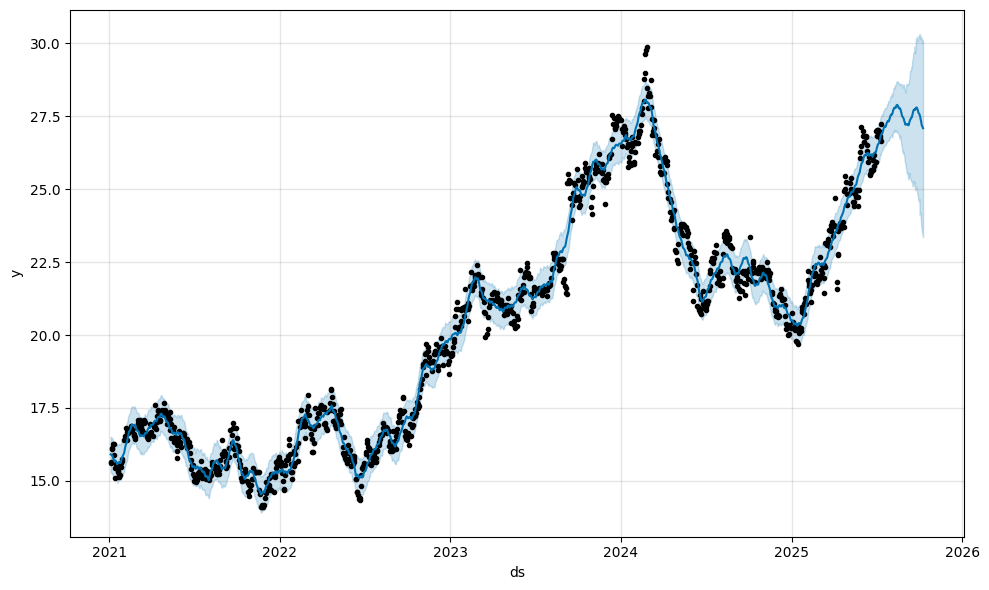

In [49]:
# Gráfico general con línea de predicción y bandas de confianza
modelo_funo11.plot(forecast);

In [1]:
# Gráficos por componente: tendencia, estacionalidad, etc.
modelo_funo11.plot_components(forecast);

NameError: name 'modelo_funo11' is not defined

In [25]:
def forecastPrice(ticker, periods=90, FHi='2023-01-01', FHe=""):
  # 📦 Librerías necesarias
  import pickle
  import os
  import pandas as pd
  import yfinance as yf
  import matplotlib.pyplot as plt
  from datetime import datetime

  # 📁 Cargar modelo
  ticker = ticker.upper()
  ticker_id = ticker.lower().replace('.', '').replace('-', '')
  nombre_archivo = f'model_{ticker_id}.pkl'
  carpeta_modelos = '/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/'
  modelo_path = os.path.join(carpeta_modelos, nombre_archivo)
  with open(modelo_path, 'rb') as f:
    modelo = pickle.load(f)

  # 📈 Descargar datos históricos actualizados
  if FHe == "":
    FHe = datetime.today().strftime('%Y-%m-%d')
  DatAss = yf.download(ticker, start=FHi, end=FHe, auto_adjust=True)['Close']
  df_prophet = DatAss.reset_index().copy()
  df_prophet['ds'] = DatAss.index
  df_prophet['y'] = df_prophet[ticker]
  df_prophet = df_prophet[['ds', 'y']]

  # 🔮 Generar pronóstico
  future = modelo.make_future_dataframe(periods=periods)
  forecast = modelo.predict(future)

  # 📊 Gráficos
  modelo.plot(forecast)
  plt.title(f'Price forecast for {ticker}')
  plt.xlabel("Date")
  plt.ylabel("Closure price")
  plt.grid(True, linestyle='--', alpha=0.4)
  plt.tight_layout()
  plt.legend()
  plt.show()

  modelo.plot_components(forecast)
  plt.title(f'Price components of {ticker}')
  plt.grid(True, linestyle='--', alpha=0.4)
  plt.tight_layout()
  plt.legend()
  plt.show()

  # 📍 Mostrar precios estimados en los próximos 5 días
  pred_5_dias = forecast[forecast['ds']>=FHe][['ds', 'yhat']].head(5)
  print("📆 Pronóstico para los próximos 5 días:")
  print(pred_5_dias.to_string(index=False))

[*********************100%***********************]  1 of 1 completed


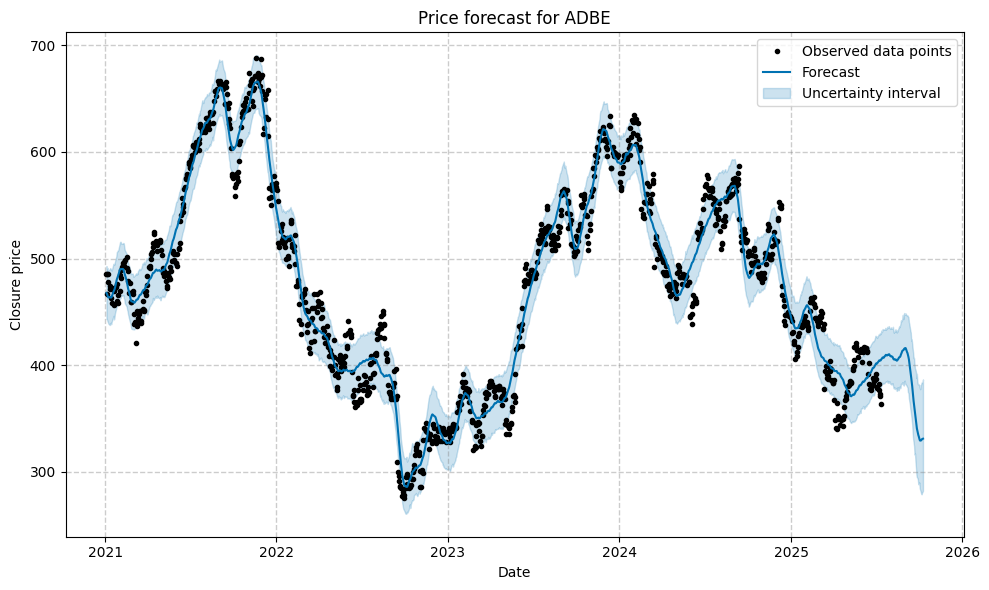

/tmp/ipython-input-25-1604987084.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


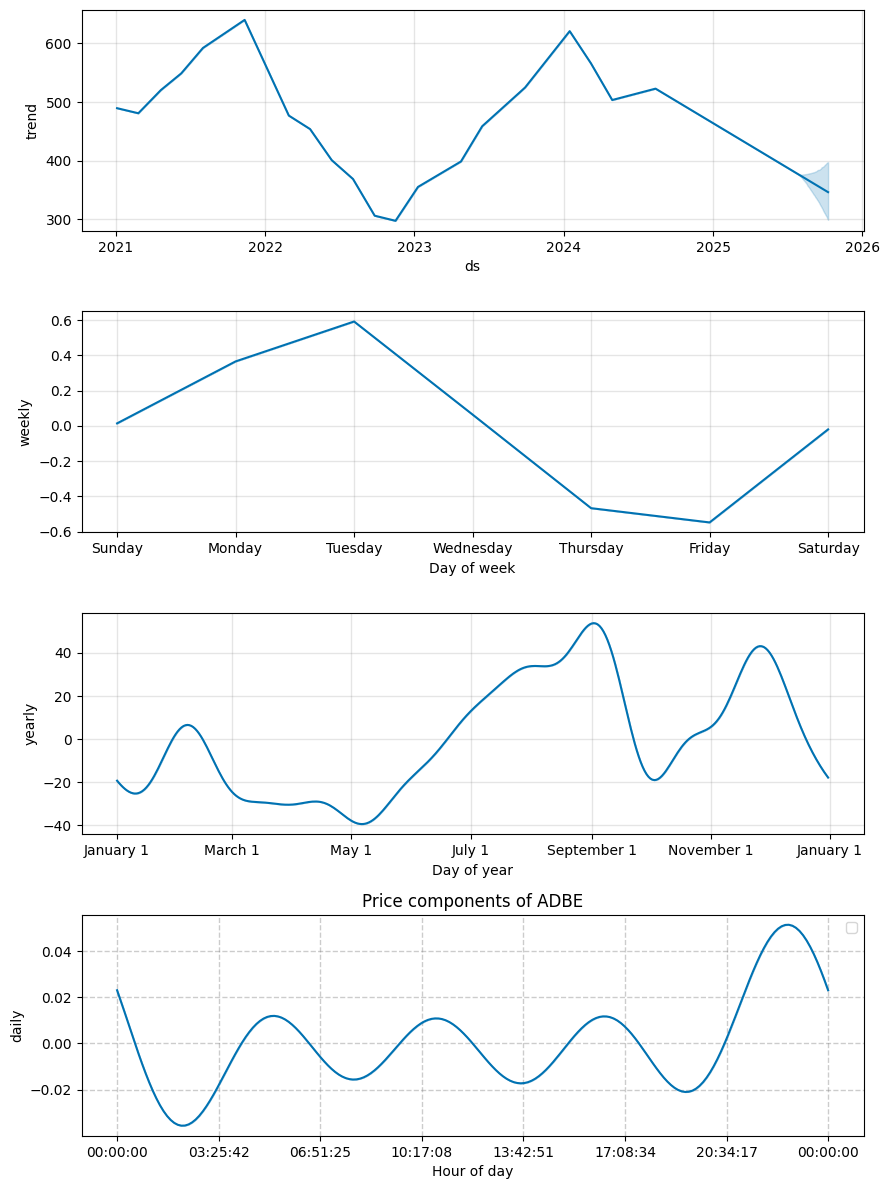

📆 Pronóstico para los próximos 5 días:
        ds       yhat
2025-07-14 406.641613
2025-07-15 407.259567
2025-07-16 407.123370
2025-07-17 406.980819
2025-07-18 407.280606


In [26]:
forecastPrice('ADBE')

In [17]:
FHi='2023-01-01'
FHe = datetime.today().strftime('%Y-%m-%d')
yf.download('ADBE', start=FHi, end=FHe, auto_adjust=True)['Close']

[*********************100%***********************]  1 of 1 completed


Ticker,ADBE
Date,
2023-01-03,336.920013
2023-01-04,341.410004
2023-01-05,328.440002
2023-01-06,332.750000
2023-01-09,341.980011
...,...
2025-07-07,376.929993
2025-07-08,382.239990
2025-07-09,373.380005
